# 07 - NLI Ablation: Retrieval × Classifier Sweep (ContraDoc)

This notebook runs the **NLI-side** of the pipeline ablation. It scores **all four retrieval variants** with **both NLI variants** (Base and Fine-tuned) so we can isolate where each pipeline stage earns its place.

## Variants
- **Retrieval**:
  - All-pairs - every $C(N, 2)$ chunk pair per doc, no retrieval. Upper bound on NLI-reachable recall.
  - Structural only - structural Cypher patterns S-SR / S-SO from notebook 04.
  - Vector only - SBERT vector top-k from notebook 05.
  - Vector + KG - union (current pipeline).
- **Classifier**:
  - NLI-Base: `cross-encoder/nli-deberta-v3-base` off-the-shelf.
  - NLI-FT: same backbone, 2-class binary head fine-tuned in `06_NLI_finetune_ContraDoc.ipynb`.

## Key design choice
Score the *all-pairs* superset once, then mark each pair with `in_struct`/`in_vector` flags so retrieval slicing happens at evaluation time without re-running NLI. One unified output (`predictions_ablation.jsonl`) drives notebook 08.

## Inputs / outputs
- **In**: `triples_minie.jsonl` (sentence inventory + gold), `chunk_candidates.jsonl` (retrieval flags), NLI-FT checkpoint at `../fine-tuning/models/nli_binary/`
- **Out**: `predictions_ablation.jsonl`, `ablation_07_summary.json`, plots in `plots/07_NLI_ablation/`


In [1]:
import csv
import itertools
import json
from collections import defaultdict
from pathlib import Path

import numpy as np
import torch
from sentence_transformers import CrossEncoder
from tqdm.auto import tqdm
from transformers import AutoModelForSequenceClassification, AutoTokenizer

TRIPLES_PATH     = Path("data/processed/ContraDoc/triples_minie.jsonl")
CANDIDATES_PATH  = Path("data/processed/ContraDoc/chunk_candidates.jsonl")
OUTPUT_PATH      = Path("data/processed/ContraDoc/predictions_ablation.jsonl")
SUMMARY_PATH     = Path("data/processed/ContraDoc/ablation_07_summary.json")
TRAIN_CSV        = Path("data/processed/ContraDoc/nli/nli_train.csv")
VAL_CSV          = Path("data/processed/ContraDoc/nli/nli_val.csv")

NLI_BASE_MODEL   = "cross-encoder/nli-deberta-v3-base"
NLI_FT_MODEL_DIR = Path("../fine-tuning/models/nli_binary")
BATCH_SIZE       = 32
MAX_LEN          = 256

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

device: cuda


## 1. Load gold + sentence inventory from `triples_minie.jsonl`

Same gold-pair construction as notebooks 04, 05, 06 (intra-chunk pairs where `gold_evidence_sentence_id == gold_ref_sentence_id` are excluded).


In [2]:
docs = {}
with TRIPLES_PATH.open(encoding="utf-8") as f:
    for line in f:
        r = json.loads(line)
        docs[r["doc_id"]] = {
            "contradiction": r["contradiction"],
            "contra_type":   r.get("contra_type") or "",
            "gold_evidence_sentence_id": r.get("gold_evidence_sentence_id"),
            "gold_ref_sentence_ids":     r.get("gold_ref_sentence_ids") or [],
            "sentences": [(s["sentence_id"], s["source_text"]) for s in r["sentences"]],
        }

print(f"Loaded {len(docs)} docs from {TRIPLES_PATH}")
n_yes = sum(1 for d in docs.values() if d["contradiction"] == "YES")
print(f"  contradiction YES: {n_yes}  NO: {len(docs) - n_yes}")
total_sents = sum(len(d["sentences"]) for d in docs.values())
total_pairs = sum(len(d["sentences"]) * (len(d["sentences"]) - 1) // 2 for d in docs.values())
print(f"  total sentences: {total_sents:,}  total all-pairs: {total_pairs:,}")


def pkey(a, b):
    return (a, b) if a < b else (b, a)


gold_pairs = set()
for doc_id, d in docs.items():
    ev = d["gold_evidence_sentence_id"]
    if d["contradiction"] != "YES" or ev is None or not d["gold_ref_sentence_ids"]:
        continue
    for ref in d["gold_ref_sentence_ids"]:
        if ev == ref:
            continue
        gold_pairs.add(pkey((doc_id, ev), (doc_id, ref)))

n_gold_docs = len({p[0][0] for p in gold_pairs})
print(f"\nGold chunk pairs: {len(gold_pairs)} across {n_gold_docs} docs (intra-cases excluded)")

doc_types = {
    d_id: [t for t in d["contra_type"].split("|") if t]
    for d_id, d in docs.items() if d["contradiction"] == "YES"
}

Loaded 150 docs from data\processed\ContraDoc\triples_minie.jsonl
  contradiction YES: 150  NO: 0
  total sentences: 5,651  total all-pairs: 122,802

Gold chunk pairs: 122 across 118 docs (intra-cases excluded)


## 2. Mark retrieval flags from `chunk_candidates.jsonl`

`chunk_candidates.jsonl` carries the union of KG (S-Union from notebook 04) and Vector retrieval (top-k SBERT from notebook 05). The `source` field is `"struct"`, `"vector"`, or `"struct+vector"`.

We compute two membership sets so every pair (including all-pairs not in the retrieval) can be tagged with `in_struct` / `in_vector` flags.


In [3]:
struct_pairs = set()
vector_pairs = set()
all_retrieved = set()

with CANDIDATES_PATH.open(encoding="utf-8") as f:
    for line in f:
        c = json.loads(line)
        pk = pkey((c["doc_id"], c["chunk_a"]["sentence_id"]),
                  (c["doc_id"], c["chunk_b"]["sentence_id"]))
        all_retrieved.add(pk)
        if c["source"] in ("struct", "struct+vector"):
            struct_pairs.add(pk)
        if c["source"] in ("vector", "struct+vector"):
            vector_pairs.add(pk)

print(f"Retrieval candidate counts:")
print(f"  Total retrieved (Vector ∪ KG): {len(all_retrieved):,}")
print(f"  KG (struct):                   {len(struct_pairs):,}")
print(f"  Vector:                        {len(vector_pairs):,}")
print(f"  Both (intersection):           {len(struct_pairs & vector_pairs):,}")
print(f"\nGold-pair coverage by retrieval:")
print(f"  ALL gold:        {len(gold_pairs)}")
print(f"  in retrieval:    {len(gold_pairs & all_retrieved)}")
print(f"  in KG:           {len(gold_pairs & struct_pairs)}")
print(f"  in Vector:       {len(gold_pairs & vector_pairs)}")

Retrieval candidate counts:
  Total retrieved (Vector ∪ KG): 3,635
  KG (struct):                   878
  Vector:                        3,000
  Both (intersection):           243

Gold-pair coverage by retrieval:
  ALL gold:        122
  in retrieval:    76
  in KG:           55
  in Vector:       70


## 3. Build all-pairs candidate set with retrieval flags

Each pair gets:
- `is_gold_pair`: matches the gold set
- `in_struct` / `in_vector`: which retrieval source(s) found it
- Pairs with both flags False are present *only* in the all-pairs variant


In [4]:
pairs = []
for doc_id, d in docs.items():
    for (sid_a, text_a), (sid_b, text_b) in itertools.combinations(d["sentences"], 2):
        pk = pkey((doc_id, sid_a), (doc_id, sid_b))
        pairs.append({
            "doc_id":       doc_id,
            "chunk_a":      {"sentence_id": sid_a, "source_text": text_a},
            "chunk_b":      {"sentence_id": sid_b, "source_text": text_b},
            "in_struct":    pk in struct_pairs,
            "in_vector":    pk in vector_pairs,
            "is_gold_pair": pk in gold_pairs,
        })

n_pairs = len(pairs)
n_gold_in_set = sum(1 for p in pairs if p["is_gold_pair"])
n_struct  = sum(1 for p in pairs if p["in_struct"])
n_vector  = sum(1 for p in pairs if p["in_vector"])
n_union   = sum(1 for p in pairs if p["in_struct"] or p["in_vector"])

print(f"Generated {n_pairs:,} total pairs")
print(f"Gold pairs present: {n_gold_in_set} / {len(gold_pairs)} (others = intra-chunk or extracted-out sentences)")
print()
print(f"Per-variant pool sizes:")
print(f"  All-pairs:   {n_pairs:>7,}")
print(f"  Structural only:     {n_struct:>7,}")
print(f"  Vector only: {n_vector:>7,}")
print(f"  Vector+Structural:   {n_union:>7,}")

Generated 122,802 total pairs
Gold pairs present: 122 / 122 (others = intra-chunk or extracted-out sentences)

Per-variant pool sizes:
  All-pairs:   122,802
  KG only:         878
  Vector only:   3,000
  Vector+KG:     3,635


## 4. Leakage check (doc_id-strict, base-soft policy)

Same policy as notebook 06: train/val splits MUST not share `doc_id` with the eval pool, but `base_doc_id` overlap is allowed (in-domain fine-tuning by design — variants of the same base doc are siblings, not duplicates).


In [5]:
def csv_field_set(path, field):
    out = set()
    with path.open(encoding="utf-8") as f:
        for r in csv.DictReader(f):
            out.add(r[field])
    return out

train_doc_ids = csv_field_set(TRAIN_CSV, "doc_id")
val_doc_ids   = csv_field_set(VAL_CSV,   "doc_id")
train_bases   = csv_field_set(TRAIN_CSV, "base_doc_id")
val_bases     = csv_field_set(VAL_CSV,   "base_doc_id")

eval_doc_ids = set(docs.keys())
eval_bases   = {d.split("_")[0] for d in eval_doc_ids}

train_doc_overlap = train_doc_ids & eval_doc_ids
val_doc_overlap   = val_doc_ids   & eval_doc_ids
assert not train_doc_overlap, f"LEAKAGE: train ∩ eval (doc_id) = {train_doc_overlap}"
assert not val_doc_overlap,   f"LEAKAGE: val ∩ eval (doc_id) = {val_doc_overlap}"

print("Leakage check (doc_id strict, base soft):")
print(f"  train ∩ eval doc_ids:  0 (asserted)")
print(f"  val   ∩ eval doc_ids:  0 (asserted)")
print(f"  train ∩ eval bases:    {len(train_bases & eval_bases)} (in-domain overlap allowed)")
print(f"  val   ∩ eval bases:    {len(val_bases   & eval_bases)} (in-domain overlap allowed)")

Leakage check (doc_id strict, base soft):
  train ∩ eval doc_ids:  0 (asserted)
  val   ∩ eval doc_ids:  0 (asserted)
  train ∩ eval bases:    34 (in-domain overlap allowed)
  val   ∩ eval bases:    9 (in-domain overlap allowed)


## 5. Score with NLI-Base

Off-the-shelf 3-class CrossEncoder. Adds `nli_base_*` fields to every pair.


In [6]:
base_model = CrossEncoder(NLI_BASE_MODEL)
base_id2label = base_model.config.id2label
base_label2id = {v.lower(): int(k) for k, v in base_id2label.items()}
BASE_CONTRA_IDX  = base_label2id["contradiction"]
BASE_ENTAIL_IDX  = base_label2id["entailment"]
BASE_NEUTRAL_IDX = base_label2id["neutral"]
print(f"NLI-Base id2label: {base_id2label}")

texts = [(p["chunk_a"]["source_text"], p["chunk_b"]["source_text"]) for p in pairs]
print(f"Scoring {len(texts):,} pairs with NLI-Base...")
base_scores = base_model.predict(texts, batch_size=BATCH_SIZE, show_progress_bar=True, apply_softmax=True)
base_scores = np.asarray(base_scores)

for p, s in zip(pairs, base_scores):
    p["nli_base_contradiction"] = float(s[BASE_CONTRA_IDX])
    p["nli_base_entailment"]    = float(s[BASE_ENTAIL_IDX])
    p["nli_base_neutral"]       = float(s[BASE_NEUTRAL_IDX])
    p["nli_base_pred"]          = base_id2label[int(np.argmax(s))].lower()

print(f"Done. Score shape: {base_scores.shape}")

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

NLI-Base id2label: {0: 'contradiction', 1: 'entailment', 2: 'neutral'}
Scoring 122,802 pairs with NLI-Base...


Batches:   0%|          | 0/3838 [00:00<?, ?it/s]

Done. Score shape: (122802, 3)


## 6. Score with NLI-Fine-tuned

Binary 2-class head. `softmax[:, 1]` is the contradiction probability used for thresholding.


In [7]:
ft_tokenizer = AutoTokenizer.from_pretrained(NLI_FT_MODEL_DIR)
ft_model = AutoModelForSequenceClassification.from_pretrained(NLI_FT_MODEL_DIR).to(device)
ft_model.eval()
print(f"NLI-FT id2label: {ft_model.config.id2label}")

premises   = [p["chunk_a"]["source_text"] for p in pairs]
hypotheses = [p["chunk_b"]["source_text"] for p in pairs]

ft_probs = np.empty((len(pairs), 2), dtype=np.float32)
print(f"Scoring {len(pairs):,} pairs with NLI-FT...")
with torch.no_grad():
    for start in tqdm(range(0, len(pairs), BATCH_SIZE)):
        end = start + BATCH_SIZE
        enc = ft_tokenizer(
            premises[start:end], hypotheses[start:end],
            padding=True, truncation=True, max_length=MAX_LEN, return_tensors="pt",
        ).to(device)
        logits = ft_model(**enc).logits
        ft_probs[start:end] = torch.softmax(logits, dim=-1).cpu().numpy()

for p, pr in zip(pairs, ft_probs):
    p["nli_ft_not_contradiction"] = float(pr[0])
    p["nli_ft_contradiction"]     = float(pr[1])
    p["nli_ft_pred"]              = ft_model.config.id2label[int(np.argmax(pr))]

print(f"Done. Score shape: {ft_probs.shape}")

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

NLI-FT id2label: {0: 'not_contradiction', 1: 'contradiction'}
Scoring 122,802 pairs with NLI-FT...


  0%|          | 0/3838 [00:00<?, ?it/s]

Done. Score shape: (122802, 2)


## 7. Save unified predictions


In [8]:
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
with OUTPUT_PATH.open("w", encoding="utf-8") as f:
    for p in pairs:
        f.write(json.dumps(p, ensure_ascii=False) + "\n")
print(f"Saved {len(pairs):,} predictions -> {OUTPUT_PATH.resolve()}")

Saved 122,802 predictions -> D:\AT82.05-Claim-Contradiction-Over-Knowledge-Graphs\experiments\data\processed\ContraDoc\predictions_ablation.jsonl


## 8. Evaluate: best-F1 per (retrieval × classifier)

For each cell of the 4×2 grid, run a fine-grain (step=0.001) threshold search to find the F1-optimal operating point. Print one master table.


In [9]:
is_gold_arr   = np.array([p["is_gold_pair"] for p in pairs], dtype=bool)
in_struct_arr = np.array([p["in_struct"]    for p in pairs], dtype=bool)
in_vector_arr = np.array([p["in_vector"]    for p in pairs], dtype=bool)
doc_ids_arr   = np.array([p["doc_id"]       for p in pairs])

variants = {
    "All-pairs":   np.ones(len(pairs), dtype=bool),
    "Structural only":     in_struct_arr,
    "Vector only": in_vector_arr,
    "Vector+Structural":   in_struct_arr | in_vector_arr,
}
classifiers = {
    "NLI-Base": np.array([p["nli_base_contradiction"] for p in pairs]),
    "NLI-FT":   np.array([p["nli_ft_contradiction"]   for p in pairs]),
}

n_total_gold = int(is_gold_arr.sum())
gold_doc_ids = set(doc_ids_arr[is_gold_arr])
n_gold_docs  = len(gold_doc_ids)


def best_f1(scores, mask, lo=0.05, hi=0.999, step=0.001):
    s_in, g_in, d_in = scores[mask], is_gold_arr[mask], doc_ids_arr[mask]
    grid = np.arange(lo, hi + step, step)
    best = {"thr": None, "f1": -1.0, "n_pred": 0, "tp": 0, "fp": 0,
            "fn": int(g_in.sum()), "prec": 0.0, "pair_r": 0.0,
            "doc_r": 0.0, "docs_caught": 0}
    for t in grid:
        pred = s_in >= t
        tp = int((pred & g_in).sum())
        if tp == 0:
            continue
        fp = int((pred & ~g_in).sum())
        fn = int((~pred & g_in).sum())
        p_ = tp / max(tp + fp, 1)
        r_ = tp / max(tp + fn, 1)
        f1_ = 2 * p_ * r_ / max(p_ + r_, 1e-9)
        if f1_ > best["f1"]:
            doc_caught = set(d_in[pred & g_in])
            best = {"thr": float(t), "f1": float(f1_), "n_pred": int(pred.sum()),
                    "tp": tp, "fp": fp, "fn": fn,
                    "prec": p_, "pair_r": r_,
                    "doc_r": len(doc_caught) / max(n_gold_docs, 1),
                    "docs_caught": len(doc_caught)}
    return best


print(f"Gold pairs: {n_total_gold} across {n_gold_docs} docs\n")
header = f"{'Retrieval':<13} {'Classifier':<10} {'#pool':>7} {'#gold':>5} {'thr':>6} {'TP':>4} {'FP':>5} {'FN':>4} {'Prec':>6} {'Pair-R':>7} {'F1':>6} {'Doc-R':>11}"
print(header)
print("-" * len(header))

results = {}
for v_name, v_mask in variants.items():
    for c_name, c_scores in classifiers.items():
        n_pool = int(v_mask.sum())
        n_gold_in_pool = int((v_mask & is_gold_arr).sum())
        b = best_f1(c_scores, v_mask)
        results[(v_name, c_name)] = b
        thr_str = f"{b['thr']:.3f}" if b["thr"] is not None else "  -  "
        print(
            f"{v_name:<13} {c_name:<10} {n_pool:>7,} {n_gold_in_pool:>5} {thr_str:>6} "
            f"{b['tp']:>4} {b['fp']:>5,} {b['fn']:>4} "
            f"{b['prec']:>5.1%} {b['pair_r']:>6.1%} {b['f1']:>5.1%} "
            f"{b['docs_caught']:>2}/{n_gold_docs:<2} {b['doc_r']:>5.1%}"
        )

# Save summary for notebook 08 to consume
summary = []
for v_name in variants:
    for c_name in classifiers:
        b = results[(v_name, c_name)]
        summary.append({
            "retrieval":   v_name,
            "classifier":  c_name,
            "n_pool":      int(variants[v_name].sum()),
            "n_gold_pool": int((variants[v_name] & is_gold_arr).sum()),
            "n_total_gold":  n_total_gold,
            "n_gold_docs": n_gold_docs,
            **b,
        })
SUMMARY_PATH.parent.mkdir(parents=True, exist_ok=True)
with SUMMARY_PATH.open("w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)
print(f"\nSaved summary -> {SUMMARY_PATH.resolve()}")

Gold pairs: 122 across 118 docs

Retrieval     Classifier   #pool #gold    thr   TP    FP   FN   Prec  Pair-R     F1       Doc-R
-----------------------------------------------------------------------------------------------


All-pairs     NLI-Base   122,802   122  0.999   54 8,097   68  0.7%  44.3%  1.3% 54/118 45.8%


All-pairs     NLI-FT     122,802   122  0.942   45    97   77 31.7%  36.9% 34.1% 45/118 38.1%
KG only       NLI-Base       878    55  0.998   43   135   12 24.2%  78.2% 36.9% 43/118 36.4%
KG only       NLI-FT         878    55  0.917   50    27    5 64.9%  90.9% 75.8% 50/118 42.4%
Vector only   NLI-Base     3,000    70  0.999   39   241   31 13.9%  55.7% 22.3% 39/118 33.1%
Vector only   NLI-FT       3,000    70  0.942   42    22   28 65.6%  60.0% 62.7% 42/118 35.6%
Vector+KG     NLI-Base     3,635    76  0.998   53   417   23 11.3%  69.7% 19.4% 53/118 44.9%
Vector+KG     NLI-FT       3,635    76  0.941   46    31   30 59.7%  60.5% 60.1% 46/118 39.0%

Saved summary -> D:\AT82.05-Claim-Contradiction-Over-Knowledge-Graphs\experiments\data\processed\ContraDoc\ablation_07_summary.json


## 9. Plots

- **F1 grid**: bar chart, retrieval × classifier
- **PR curves**: NLI-FT across the 4 retrieval variants
- **Per-type heatmap**: NLI-FT recall per ContraDoc type × retrieval variant


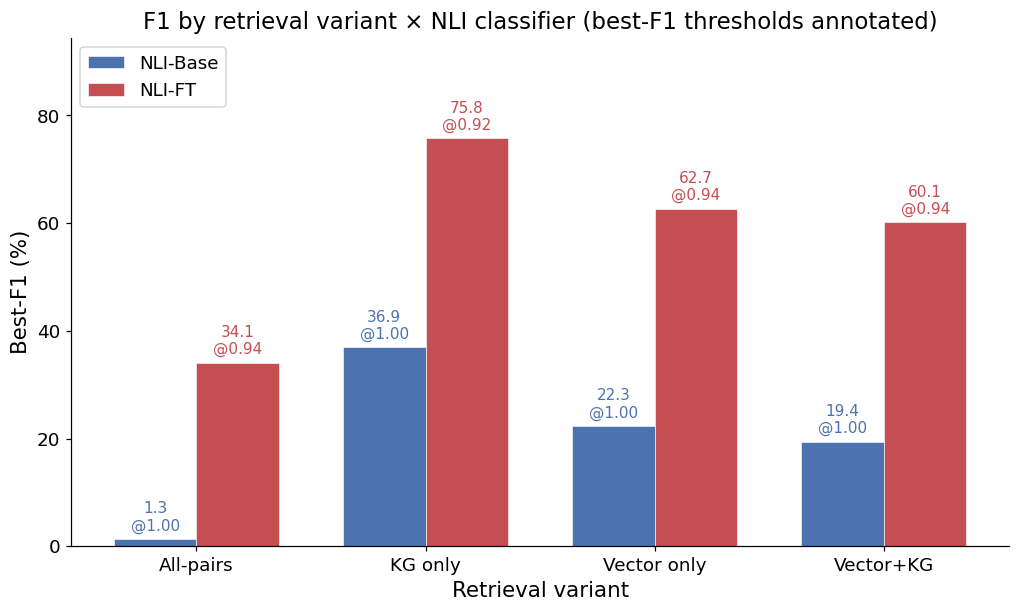

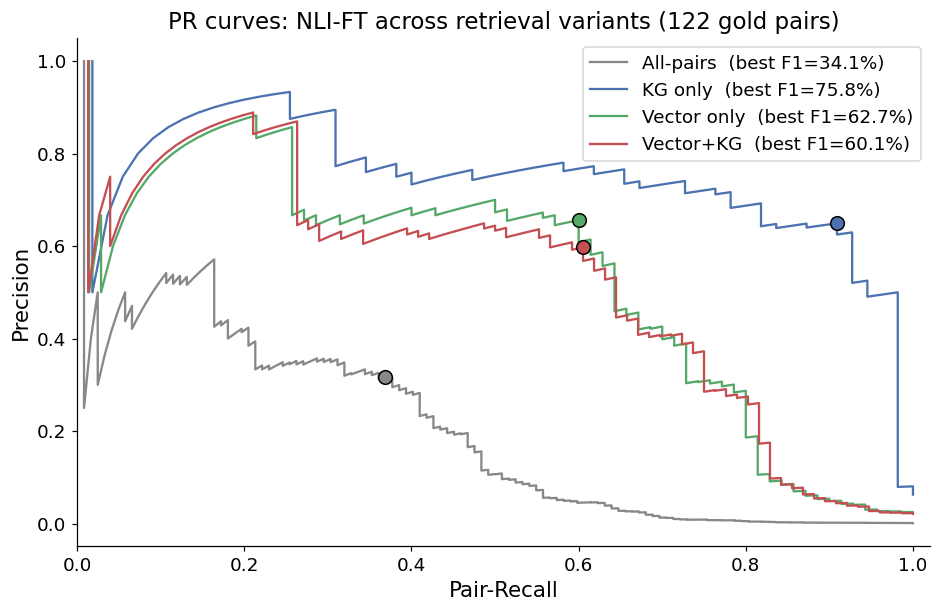

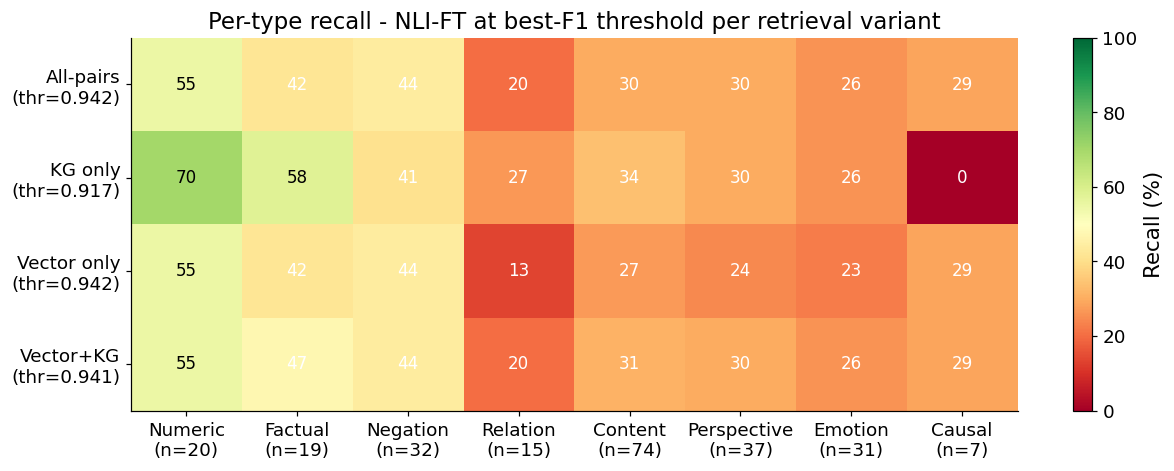

Saved plots to D:\AT82.05-Claim-Contradiction-Over-Knowledge-Graphs\experiments\plots\07_NLI_ablation


In [10]:
import matplotlib.pyplot as plt

PLOT_DIR = Path("plots/07_NLI_ablation")
PLOT_DIR.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.size": 13, "axes.titlesize": 15, "axes.labelsize": 14,
    "xtick.labelsize": 12, "ytick.labelsize": 12, "legend.fontsize": 12,
    "figure.titlesize": 15, "axes.spines.top": False, "axes.spines.right": False,
})
C_BLUE, C_RED, C_GREEN, C_GREY = "#4C72B0", "#C44E52", "#55A868", "#888888"

v_order = ["All-pairs", "Structural only", "Vector only", "Vector+Structural"]
c_order = ["NLI-Base", "NLI-FT"]

# --- Plot 1: F1 grouped bars ---
f1_matrix = np.array([[results[(v, c)]["f1"] * 100 for c in c_order] for v in v_order])
x = np.arange(len(v_order))
w = 0.36
fig, ax = plt.subplots(figsize=(11, 6))
ax.bar(x - w / 2, f1_matrix[:, 0], w, label="NLI-Base", color=C_BLUE, edgecolor="white", linewidth=0.4)
ax.bar(x + w / 2, f1_matrix[:, 1], w, label="NLI-FT",   color=C_RED,  edgecolor="white", linewidth=0.4)
for i in range(len(v_order)):
    for j, color in enumerate([C_BLUE, C_RED]):
        f1_val = f1_matrix[i, j]
        thr = results[(v_order[i], c_order[j])]["thr"]
        thr_lbl = f"{thr:.2f}" if thr is not None else "-"
        ax.text(x[i] + (-w / 2 if j == 0 else w / 2), f1_val + 1,
                f"{f1_val:.1f}\n@{thr_lbl}", ha="center", va="bottom",
                fontsize=10, color=color)
ax.set_xticks(x)
ax.set_xticklabels(v_order)
ax.set_xlabel("Retrieval variant")
ax.set_ylabel("Best-F1 (%)")
ax.set_title("F1 by retrieval variant × NLI classifier (best-F1 thresholds annotated)")
ax.set_ylim(0, max(f1_matrix.max() * 1.18 + 5, 10))
ax.legend(loc="upper left")
fig.savefig(PLOT_DIR / "f1_grid.png")
plt.show()

# --- Plot 2: PR curves for NLI-FT across retrieval variants ---
ft_scores = classifiers["NLI-FT"]
fig, ax = plt.subplots(figsize=(10, 6))
colors = [C_GREY, C_BLUE, C_GREEN, C_RED]
for v, color in zip(v_order, colors):
    mask = variants[v]
    s_in = ft_scores[mask]
    g_in = is_gold_arr[mask]
    if g_in.sum() == 0:
        continue
    order = np.argsort(-s_in)
    g_sorted = g_in[order]
    tp = np.cumsum(g_sorted)
    fp = np.cumsum(~g_sorted)
    prec = tp / np.maximum(tp + fp, 1)
    rec  = tp / max(int(g_in.sum()), 1)
    op = results[(v, "NLI-FT")]
    ax.plot(rec, prec, color=color, label=f"{v}  (best F1={op['f1']:.1%})")
    ax.scatter([op["pair_r"]], [op["prec"]], s=80, color=color, edgecolor="black", zorder=5)
ax.set_xlabel("Pair-Recall")
ax.set_ylabel("Precision")
ax.set_title(f"PR curves: NLI-FT across retrieval variants ({n_total_gold} gold pairs)")
ax.legend(loc="upper right")
ax.set_xlim(0, 1.02)
fig.savefig(PLOT_DIR / "pr_curves_ft.png")
plt.show()

# --- Plot 3: Per-type recall heatmap (NLI-FT only) ---
type_order = ["Numeric", "Factual", "Negation", "Relation",
              "Content", "Perspective/View/Opinion", "Emotion/Mood/Feeling", "Causal"]
type_totals = {t: 0 for t in type_order}
for p in gold_pairs:
    for t in doc_types.get(p[0][0], []):
        if t in type_totals:
            type_totals[t] += 1

heatmap_rows = []
heatmap_labels = []
for v in v_order:
    thr = results[(v, "NLI-FT")]["thr"]
    if thr is None:
        recalls = [0.0] * len(type_order)
    else:
        flagged_pairs = set()
        for i, p in enumerate(pairs):
            if variants[v][i] and ft_scores[i] >= thr:
                flagged_pairs.add(pkey((p["doc_id"], p["chunk_a"]["sentence_id"]),
                                       (p["doc_id"], p["chunk_b"]["sentence_id"])))
        recalls = []
        for t in type_order:
            caught = sum(1 for gp in gold_pairs
                         if t in doc_types.get(gp[0][0], []) and gp in flagged_pairs)
            recalls.append(caught / max(type_totals[t], 1) * 100)
    heatmap_rows.append(recalls)
    thr_lbl = f"{thr:.3f}" if thr is not None else "-"
    heatmap_labels.append(f"{v}\n(thr={thr_lbl})")

heatmap_arr = np.array(heatmap_rows)
fig, ax = plt.subplots(figsize=(13, max(3.5, 0.85 * len(heatmap_labels) + 1)))
im = ax.imshow(heatmap_arr, aspect="auto", cmap="RdYlGn", vmin=0, vmax=100)
ax.set_xticks(np.arange(len(type_order)))
short = {"Perspective/View/Opinion": "Perspective", "Emotion/Mood/Feeling": "Emotion"}
ax.set_xticklabels([f"{short.get(t, t)}\n(n={type_totals[t]})" for t in type_order], rotation=0)
ax.set_yticks(np.arange(len(heatmap_labels)))
ax.set_yticklabels(heatmap_labels)
for i in range(len(heatmap_labels)):
    for j in range(len(type_order)):
        ax.text(j, i, f"{heatmap_arr[i, j]:.0f}", ha="center", va="center",
                color="black" if heatmap_arr[i, j] > 50 else "white", fontsize=11)
fig.colorbar(im, ax=ax, label="Recall (%)")
ax.set_title("Per-type recall - NLI-FT at best-F1 threshold per retrieval variant")
fig.savefig(PLOT_DIR / "per_type_recall_heatmap.png")
plt.show()

print(f"Saved plots to {PLOT_DIR.resolve()}")